In [1]:
# --- 日本語フォント設定（Google Colab対応） ---
!pip -q install japanize-matplotlib

# Google Colab / Jupyter 実行用
# R/S解析 と DFA を、(1) ランダムウォーク系列 と (2) Yahoo FinanceのUSDJPY（日次）に適用し、
# 各計算ステップの中間量をグラフで確認するコードです。
#
# 使い方：
# 1) そのまま実行
# 2) 下の設定（DEMO_SCALEなど）を調整
#
# 注意：
# - Yahoo Finance取得には yfinance を使用します（ネット接続が必要）
# - seabornは使いません（matplotlibのみ）

!pip -q install yfinance

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from dataclasses import dataclass
import japanize_matplotlib

from scipy.stats import linregress

np.random.seed(23)

import matplotlib.pyplot as plt
from matplotlib import font_manager, rcParams

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 31.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


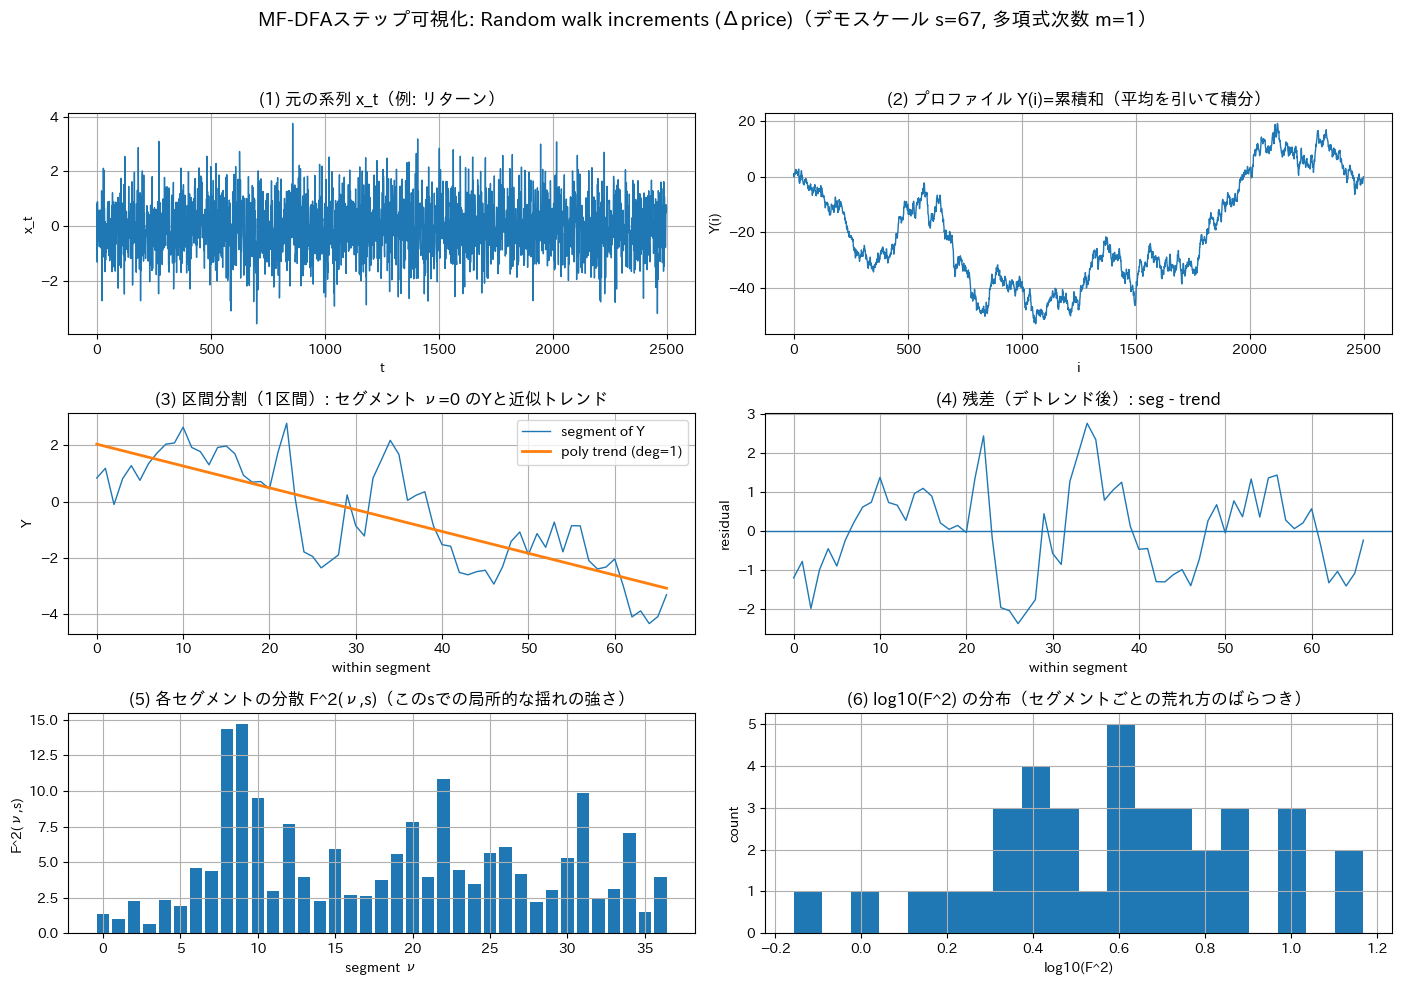

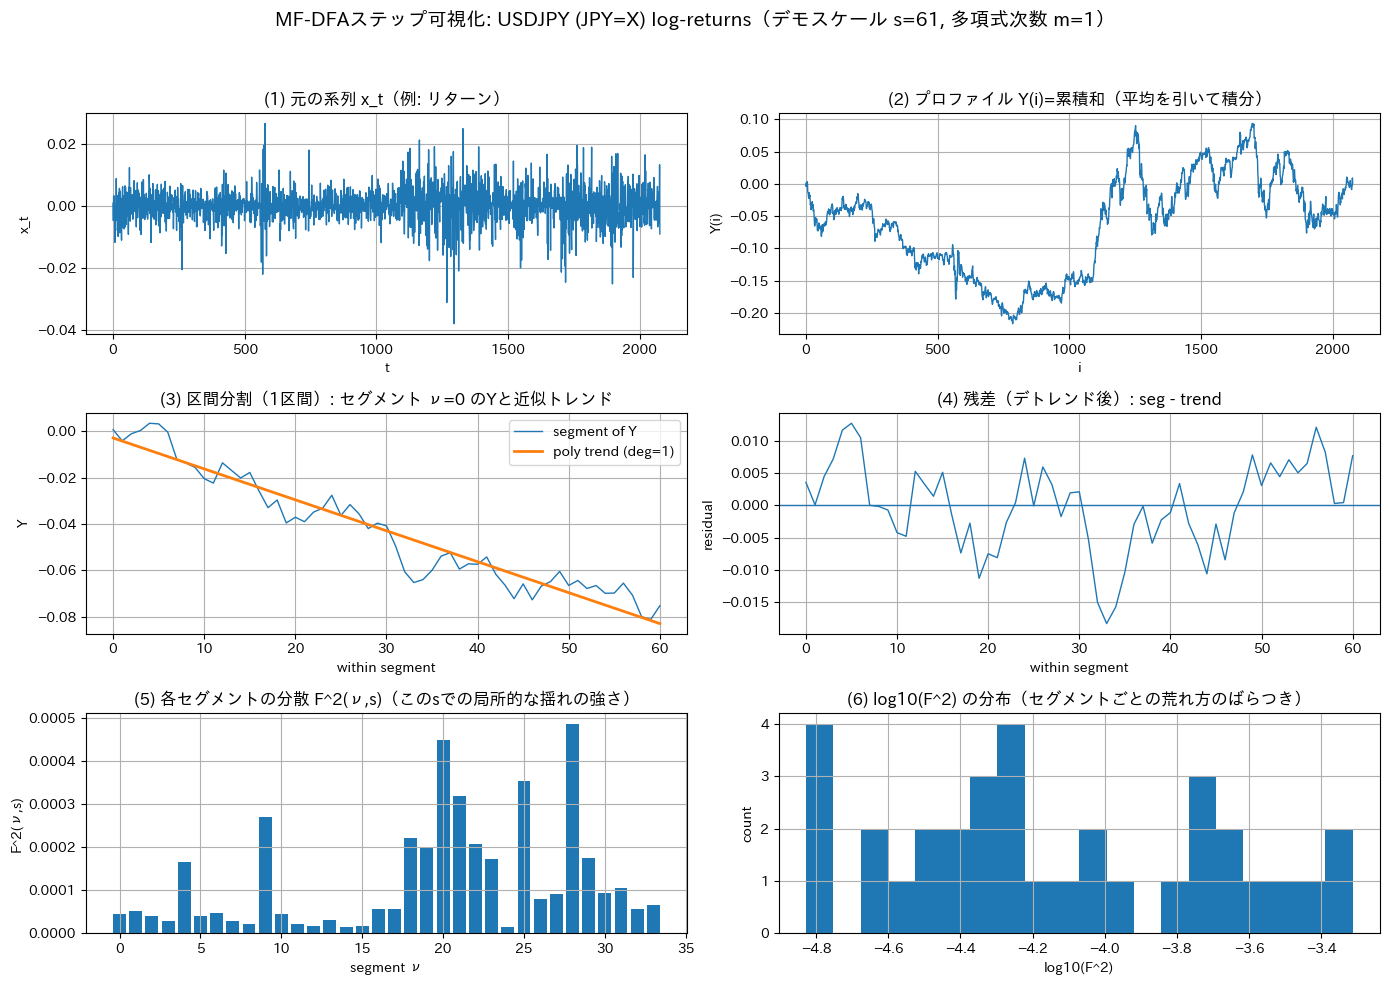

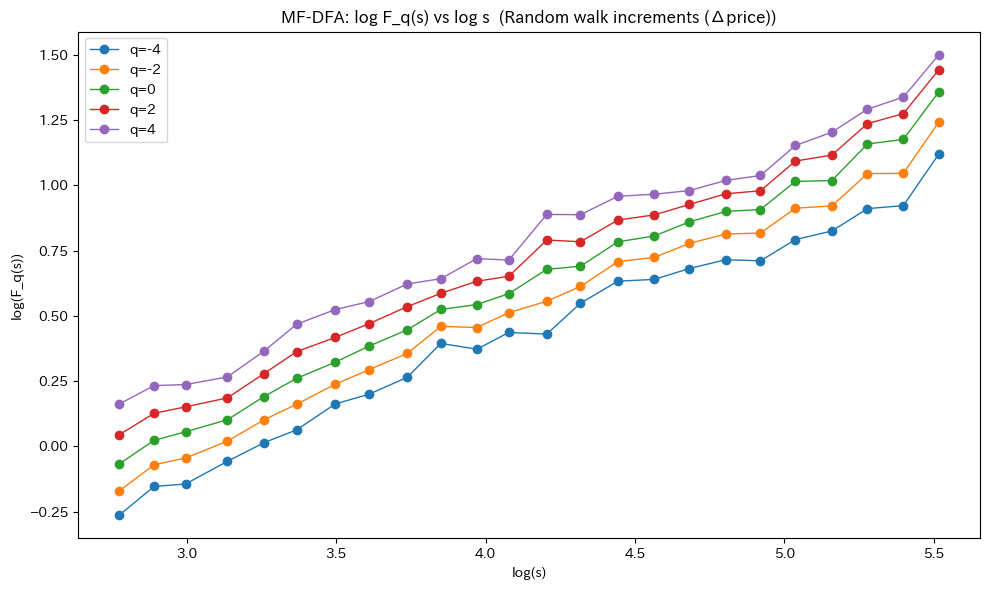

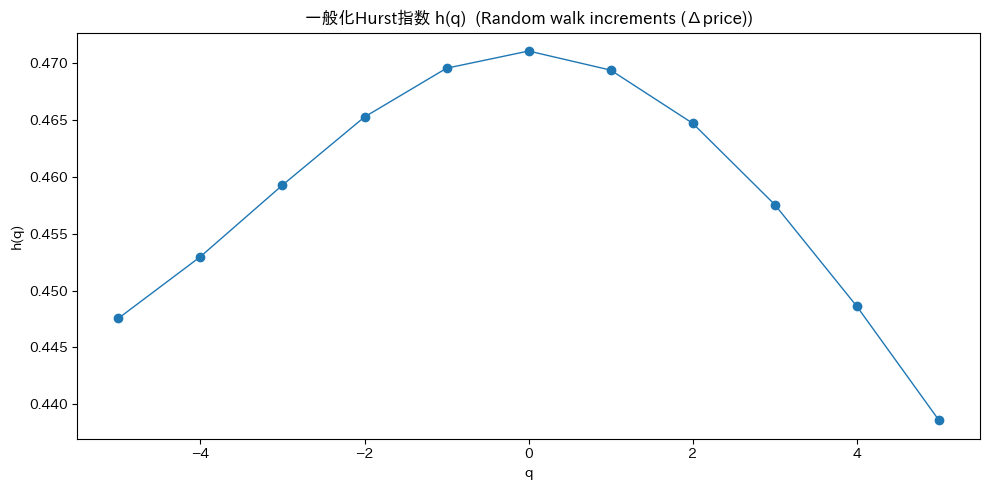

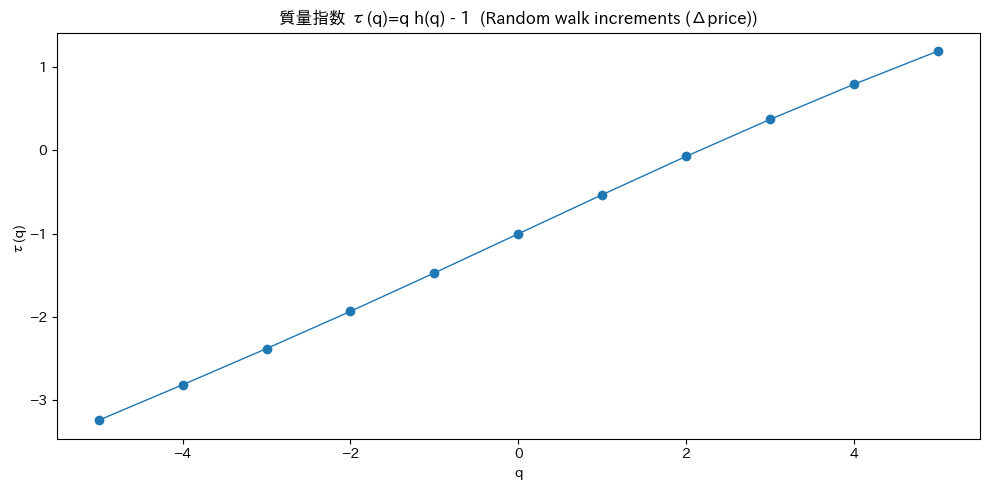

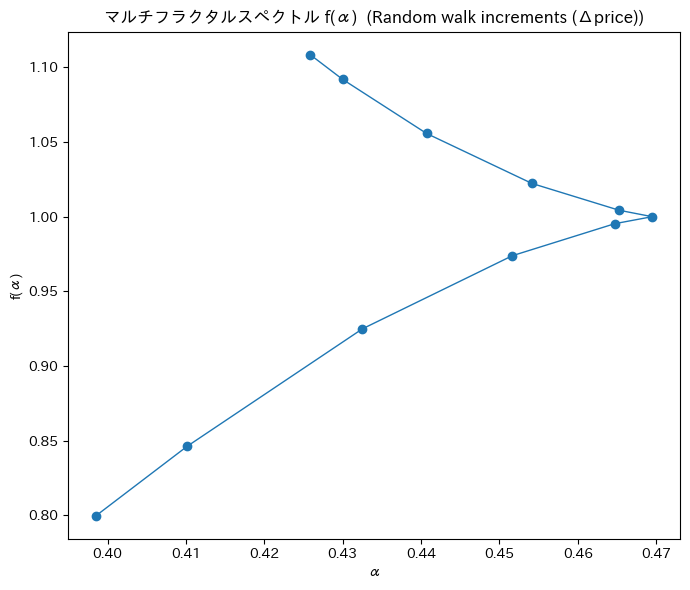

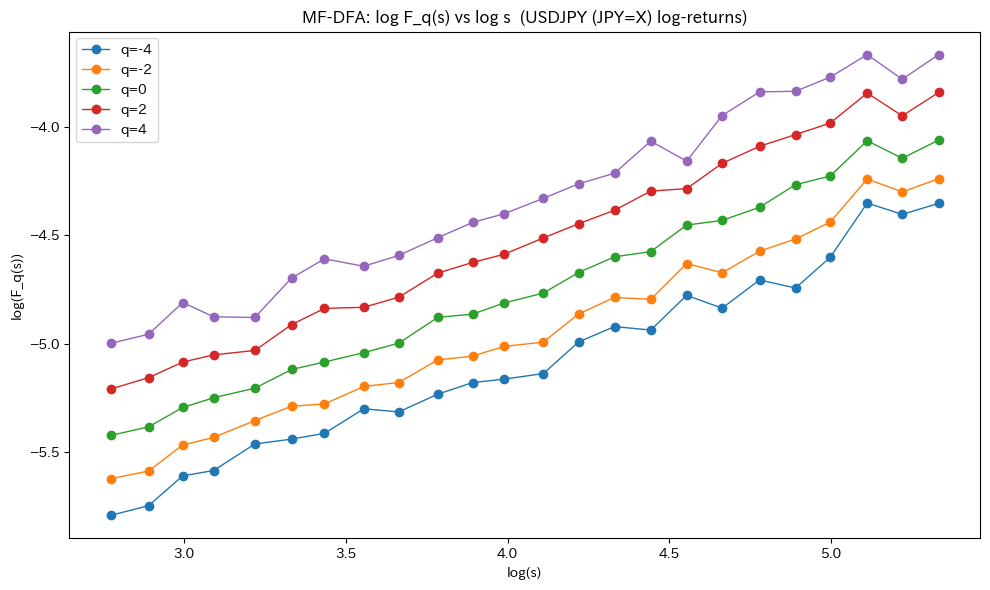

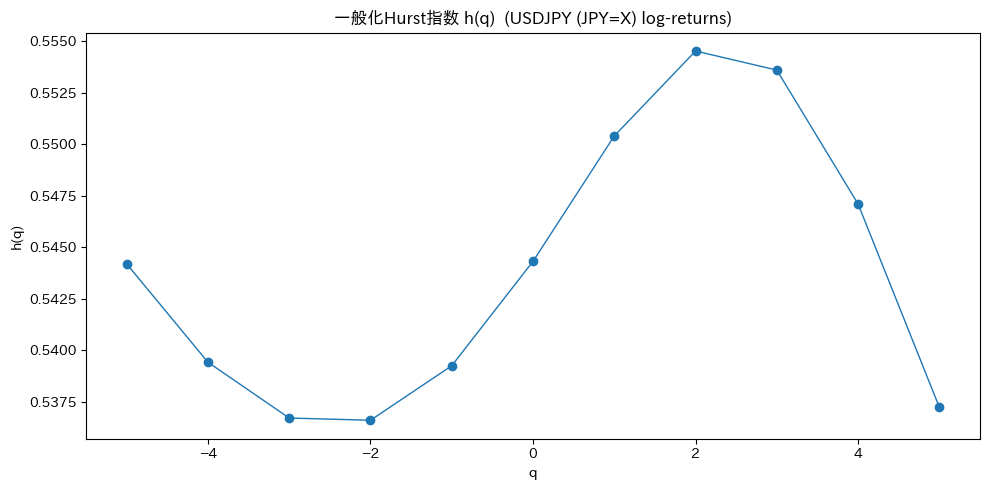

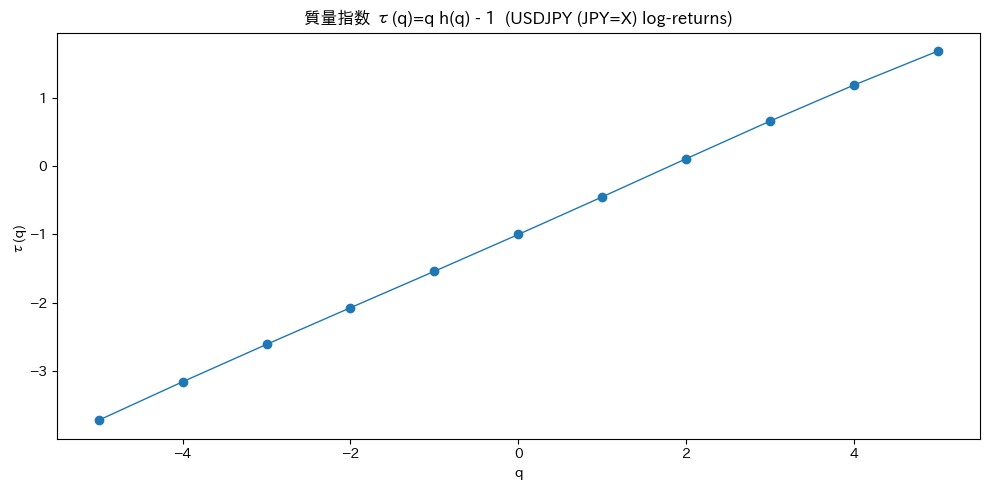

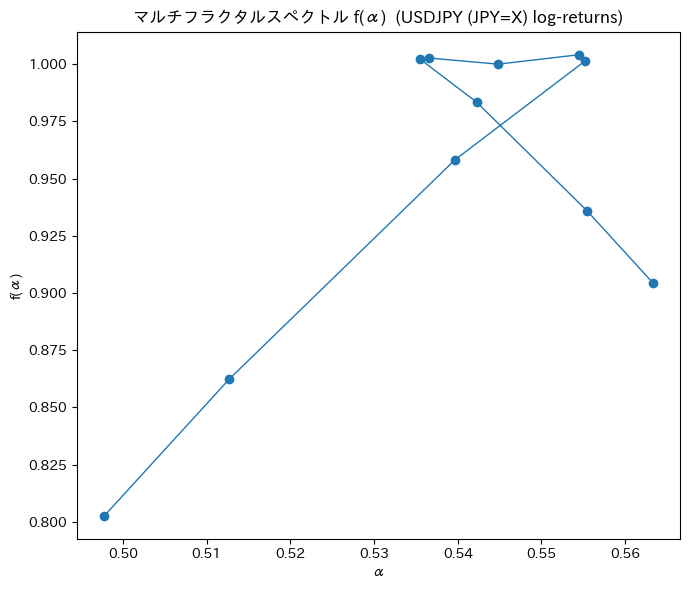

[Summary] Random Walk: {'hq_range': 0.032477404587169356, 'hq_at_q2': 0.46471109045522435, 'spec_width': 0.07093823871658955}
[Summary] USDJPY: {'hq_range': 0.017918929297563113, 'hq_at_q2': 0.5545277878488084, 'spec_width': 0.06551402247335059}


In [4]:
"""
MF-DFA (Multifractal Detrended Fluctuation Analysis) demo
- Random walk
- USDJPY from Yahoo Finance (yfinance)
- Includes step-by-step explanatory plots (one sample scale/segment) + final MF-DFA diagnostics

Requirements:
  pip install numpy pandas matplotlib yfinance scipy japanize-matplotlib

Notes:
- If Japanese fonts do not render, uncomment `import japanize_matplotlib`.
- Yahoo Finance ticker for USDJPY is typically "JPY=X" (USD/JPY). If it fails, code tries "USDJPY=X".
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Uncomment if you want easy Japanese font handling
# import japanize_matplotlib

from dataclasses import dataclass
from typing import Iterable, Tuple, Dict, Optional

try:
    import yfinance as yf
except ImportError as e:
    raise ImportError("yfinance is required. Install via: pip install yfinance") from e

from scipy.stats import linregress


# -----------------------------
# Data utilities
# -----------------------------
def make_random_walk(n: int = 2000, seed: int = 42, drift: float = 0.0, sigma: float = 1.0) -> pd.Series:
    rng = np.random.default_rng(seed)
    steps = drift + sigma * rng.standard_normal(n)
    x = np.cumsum(steps)
    idx = pd.RangeIndex(start=0, stop=n, step=1, name="t")
    return pd.Series(x, index=idx, name="RandomWalk")


def download_usdjpy(start: str = "2018-01-01", end: Optional[str] = None) -> pd.Series:
    tickers_to_try = ["JPY=X", "USDJPY=X"]
    last_err = None

    for tkr in tickers_to_try:
        try:
            df = yf.download(tkr, start=start, end=end, auto_adjust=True, progress=False)
            if df is None or df.empty:
                continue
            # Prefer Close; with auto_adjust=True, Close is adjusted
            if "Close" not in df.columns:
                continue
            s = df["Close"].dropna()
            s.name = f"USDJPY ({tkr})"
            return s
        except Exception as e:
            last_err = e
            continue

    raise RuntimeError(f"Failed to download USDJPY from Yahoo Finance. Last error: {last_err}")


def to_returns(price: pd.Series, log: bool = True) -> pd.Series:
    if log:
        r = np.log(price).diff().dropna()
        r.name = f"log-return({price.name})"
    else:
        r = price.pct_change().dropna()
        r.name = f"return({price.name})"
    return r


# -----------------------------
# MF-DFA implementation
# -----------------------------
@dataclass
class MFDFAResult:
    scales: np.ndarray
    qs: np.ndarray
    Fq: np.ndarray               # shape: (len(qs), len(scales))
    hq: np.ndarray               # shape: (len(qs),)
    tauq: np.ndarray             # shape: (len(qs),)
    alpha: np.ndarray            # shape: (len(qs),)
    falpha: np.ndarray           # shape: (len(qs),)


def _profile(x: np.ndarray) -> np.ndarray:
    """Integrated profile Y(i) = sum_{t<=i} (x_t - mean)."""
    x0 = x - np.mean(x)
    return np.cumsum(x0)


def _segment_detrended_variance(
    Y: np.ndarray, s: int, m: int
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Split Y into N_s non-overlapping segments of length s.
    For each segment, fit polynomial of degree m (least squares) and compute residual variance F^2(v,s).
    Returns:
      F2: (N_s,) array of variances
      fits: list-like of fitted trend values per segment packed in a 2D array (N_s, s) for visualization
    """
    N = len(Y)
    Ns = N // s
    if Ns < 2:
        raise ValueError("Scale too large for the series length.")

    F2 = np.zeros(Ns, dtype=float)
    fits = np.zeros((Ns, s), dtype=float)

    x_idx = np.arange(s, dtype=float)
    for v in range(Ns):
        seg = Y[v * s : (v + 1) * s]
        # polynomial fit
        coeff = np.polyfit(x_idx, seg, deg=m)
        trend = np.polyval(coeff, x_idx)
        fits[v, :] = trend
        resid = seg - trend
        F2[v] = np.mean(resid**2)
    return F2, fits


def mfdfa(
    x: np.ndarray,
    scales: Iterable[int],
    qs: Iterable[float],
    m: int = 1,
    eps: float = 1e-12
) -> MFDFAResult:
    """
    MF-DFA:
    1) build profile Y
    2) for each scale s: detrend each segment -> F^2(v,s)
    3) compute F_q(s)
       for q != 0: [mean( (F^2)^(q/2) )]^(1/q)
       for q == 0: exp( (1/2)*mean(log(F^2)) )
    4) fit log F_q(s) vs log s -> slope h(q)
    5) tau(q) = q*h(q) - 1
    6) alpha = d tau / d q, f(alpha) = q*alpha - tau(q)
    """
    x = np.asarray(x, dtype=float)
    qs = np.asarray(list(qs), dtype=float)
    scales = np.asarray(sorted(set(int(s) for s in scales)), dtype=int)

    Y = _profile(x)

    Fq = np.zeros((len(qs), len(scales)), dtype=float)

    for j, s in enumerate(scales):
        F2, _ = _segment_detrended_variance(Y, s=s, m=m)
        F2 = np.maximum(F2, eps)  # numerical safety

        for i, q in enumerate(qs):
            if np.isclose(q, 0.0):
                Fq[i, j] = np.exp(0.5 * np.mean(np.log(F2)))
            else:
                Fq[i, j] = (np.mean(F2 ** (q / 2.0))) ** (1.0 / q)

    # Estimate h(q) via linear regression on log-log
    log_s = np.log(scales.astype(float))
    hq = np.zeros(len(qs), dtype=float)

    for i in range(len(qs)):
        log_F = np.log(Fq[i, :])
        slope, intercept, r, p, se = linregress(log_s, log_F)
        hq[i] = slope

    tauq = qs * hq - 1.0

    # Legendre transform (numerical derivative)
    # alpha(q) = d tau / dq, f(alpha) = q*alpha - tau
    alpha = np.gradient(tauq, qs)
    falpha = qs * alpha - tauq

    return MFDFAResult(scales=scales, qs=qs, Fq=Fq, hq=hq, tauq=tauq, alpha=alpha, falpha=falpha)


# -----------------------------
# Visualization helpers
# -----------------------------
def pick_scales(N: int, s_min: int = 16, s_max_frac: float = 0.2, n_scales: int = 20) -> np.ndarray:
    """Log-spaced integer scales between s_min and floor(N*s_max_frac)."""
    s_max = max(s_min + 1, int(N * s_max_frac))
    vals = np.unique(np.round(np.logspace(np.log10(s_min), np.log10(s_max), n_scales)).astype(int))
    return vals


def plot_step_by_step(
    series_name: str,
    x: np.ndarray,
    Y: np.ndarray,
    s_demo: int,
    m: int,
    seg_index: int = 0
) -> None:
    """
    Explanatory plots:
      1) raw series x_t
      2) profile Y(i)
      3) one segment: Y segment + polynomial trend
      4) residuals in that segment
      5) F^2(v,s) across segments (bar)
    """
    F2, fits = _segment_detrended_variance(Y, s=s_demo, m=m)
    Ns = len(F2)
    seg_index = int(np.clip(seg_index, 0, Ns - 1))

    seg = Y[seg_index * s_demo : (seg_index + 1) * s_demo]
    trend = fits[seg_index, :]
    resid = seg - trend

    fig = plt.figure(figsize=(14, 10))
    fig.suptitle(f"MF-DFAステップ可視化: {series_name}（デモスケール s={s_demo}, 多項式次数 m={m}）", fontsize=14)

    ax1 = plt.subplot(3, 2, 1)
    ax1.plot(x, linewidth=1)
    ax1.set_title("(1) 元の系列 x_t（例: リターン）")
    ax1.set_xlabel("t")
    ax1.set_ylabel("x_t")
    ax1.grid(True)

    ax2 = plt.subplot(3, 2, 2)
    ax2.plot(Y, linewidth=1)
    ax2.set_title("(2) プロファイル Y(i)=累積和（平均を引いて積分）")
    ax2.set_xlabel("i")
    ax2.set_ylabel("Y(i)")
    ax2.grid(True)

    ax3 = plt.subplot(3, 2, 3)
    ax3.plot(seg, label="segment of Y", linewidth=1)
    ax3.plot(trend, label=f"poly trend (deg={m})", linewidth=2)
    ax3.set_title(f"(3) 区間分割（1区間）: セグメント ν={seg_index} のYと近似トレンド")
    ax3.set_xlabel("within segment")
    ax3.set_ylabel("Y")
    ax3.legend()
    ax3.grid(True)

    ax4 = plt.subplot(3, 2, 4)
    ax4.plot(resid, linewidth=1)
    ax4.axhline(0, linewidth=1)
    ax4.set_title("(4) 残差（デトレンド後）: seg - trend")
    ax4.set_xlabel("within segment")
    ax4.set_ylabel("residual")
    ax4.grid(True)

    ax5 = plt.subplot(3, 2, 5)
    ax5.bar(np.arange(Ns), F2)
    ax5.set_title("(5) 各セグメントの分散 F^2(ν,s)（このsでの局所的な揺れの強さ）")
    ax5.set_xlabel("segment ν")
    ax5.set_ylabel("F^2(ν,s)")
    ax5.grid(True)

    ax6 = plt.subplot(3, 2, 6)
    ax6.hist(np.log10(F2 + 1e-12), bins=20)
    ax6.set_title("(6) log10(F^2) の分布（セグメントごとの荒れ方のばらつき）")
    ax6.set_xlabel("log10(F^2)")
    ax6.set_ylabel("count")
    ax6.grid(True)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


def plot_mfdfa_results(series_name: str, res: MFDFAResult, qs_to_show: Iterable[float] = (-4, -2, 0, 2, 4)) -> None:
    qs_to_show = list(qs_to_show)

    # (A) log-log plot of F_q(s) for selected q
    plt.figure(figsize=(10, 6))
    for q in qs_to_show:
        # find nearest q in res.qs
        idx = int(np.argmin(np.abs(res.qs - q)))
        plt.plot(np.log(res.scales), np.log(res.Fq[idx, :]), marker="o", linewidth=1, label=f"q={res.qs[idx]:g}")
    plt.title(f"MF-DFA: log F_q(s) vs log s  ({series_name})")
    plt.xlabel("log(s)")
    plt.ylabel("log(F_q(s))")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # (B) h(q)
    plt.figure(figsize=(10, 5))
    plt.plot(res.qs, res.hq, marker="o", linewidth=1)
    plt.title(f"一般化Hurst指数 h(q)  ({series_name})")
    plt.xlabel("q")
    plt.ylabel("h(q)")
    plt.tight_layout()
    plt.show()

    # (C) tau(q)
    plt.figure(figsize=(10, 5))
    plt.plot(res.qs, res.tauq, marker="o", linewidth=1)
    plt.title(f"質量指数 τ(q)=q h(q) - 1  ({series_name})")
    plt.xlabel("q")
    plt.ylabel("τ(q)")
    plt.tight_layout()
    plt.show()

    # (D) multifractal spectrum f(alpha)
    plt.figure(figsize=(7, 6))
    plt.plot(res.alpha, res.falpha, marker="o", linewidth=1)
    plt.title(f"マルチフラクタルスペクトル f(α)  ({series_name})")
    plt.xlabel("α")
    plt.ylabel("f(α)")
    plt.tight_layout()
    plt.show()


# -----------------------------
# Main demo: Random walk & USDJPY
# -----------------------------
def run_demo():
    # ---------- Random walk ----------
    rw_price = make_random_walk(n=2500, seed=1, drift=0.0, sigma=1.0)
    # MF-DFA is commonly applied to "increments" or "returns".
    # For a random walk price, increments are the step series.
    rw_increments = rw_price.diff().dropna().values  # ~ i.i.d. normal

    # ---------- USDJPY ----------
    usdjpy_price = download_usdjpy(start="2018-01-01")
    usdjpy_ret = to_returns(usdjpy_price, log=True).values

    # ---------- MF-DFA settings ----------
    m = 1  # detrending polynomial degree (DFA1 / MF-DFA1)
    qs = np.arange(-5, 6, 1)  # q = -5..5
    # scales: choose based on length; keep max scale moderate
    # scales_rw = pick_scales(len(rw_increments), s_min=16, s_max_frac=0.2, n_scales=24)
    # scales_fx = pick_scales(len(usdjpy_ret), s_min=16, s_max_frac=0.2, n_scales=24)
    scales_rw = pick_scales(len(rw_increments), s_min=16, s_max_frac=0.1, n_scales=24)
    scales_fx = pick_scales(len(usdjpy_ret), s_min=16, s_max_frac=0.1, n_scales=24)

    # ---------- Step-by-step visualization (one sample only per series) ----------
    # Build profile explicitly to show intermediate plots
    Y_rw = _profile(rw_increments)
    Y_fx = _profile(usdjpy_ret)

    s_demo_rw = int(scales_rw[len(scales_rw) // 2])
    s_demo_fx = int(scales_fx[len(scales_fx) // 2])

    plot_step_by_step(
        series_name="Random walk increments (Δprice)",
        x=rw_increments,
        Y=Y_rw,
        s_demo=s_demo_rw,
        m=m,
        seg_index=0
    )

    plot_step_by_step(
        series_name=usdjpy_price.name + " log-returns",
        x=usdjpy_ret,
        Y=Y_fx,
        s_demo=s_demo_fx,
        m=m,
        seg_index=0
    )

    # ---------- Run MF-DFA ----------
    res_rw = mfdfa(rw_increments, scales=scales_rw, qs=qs, m=m)
    res_fx = mfdfa(usdjpy_ret, scales=scales_fx, qs=qs, m=m)

    # ---------- Final diagnostic plots ----------
    plot_mfdfa_results("Random walk increments (Δprice)", res_rw, qs_to_show=(-4, -2, 0, 2, 4))
    plot_mfdfa_results(usdjpy_price.name + " log-returns", res_fx, qs_to_show=(-4, -2, 0, 2, 4))

    # ---------- Quick textual summary ----------
    # If h(q) is roughly flat -> closer to monofractal; if varies -> multifractal-like
    def summarize(res: MFDFAResult) -> Dict[str, float]:
        return {
            "hq_range": float(np.max(res.hq) - np.min(res.hq)),
            "hq_at_q2": float(res.hq[np.argmin(np.abs(res.qs - 2))]),
            "spec_width": float(np.max(res.alpha) - np.min(res.alpha)),
        }

    print("[Summary] Random Walk:", summarize(res_rw))
    print("[Summary] USDJPY:", summarize(res_fx))


if __name__ == "__main__":
    run_demo()
